In [20]:
import sys
sys.path.insert(0, '..')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import pdf2image  # PyMuPDF
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

In [22]:

def pdf_to_image(path, zoom=2):
    images = pdf2image.convert_from_path(path, dpi=300, poppler_path='/opt/homebrew/bin')
    # gray_image = cv2.cvtColor(np.array(images[0]), cv2.COLOR_RGB2GRAY)
    return cv2.cvtColor(np.array(images[0]), cv2.COLOR_RGB2BGR)

def remove_border(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, th = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    biggest = max(contours, key=cv2.contourArea)
    x,y,w,h = cv2.boundingRect(biggest)
    margin = 150
    x = max(x + margin, 0)
    y = max(y + margin, 0)
    w = min(w - 2*margin, img.shape[1] - x)
    h = min(h - 2*margin, img.shape[0] - y)

    return img[y:y+h, x:x+w]

def binarize(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 15, 5)
    return binary

def enhance_walls(binary):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    walls = cv2.dilate(binary, kernel)
    return walls

def extract_doors(binary):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    doors = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    return doors

def extract_walls(binary):
    # horizontal
    kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
    horizontal = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_h)

    # vertical
    kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
    vertical = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_v)

    # diagonal 45°
    kernel_45 = np.eye(25, dtype=np.uint8)
    diag_45 = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_45)

    # diagonal 135°
    kernel_135 = np.fliplr(kernel_45)
    diag_135 = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_135)

    # combinar tudo
    walls = cv2.bitwise_or(horizontal, vertical)
    walls = cv2.bitwise_or(walls, diag_45)
    walls = cv2.bitwise_or(walls, diag_135)

    return walls

def detect_edges(img):
    edges = cv2.Canny(img, 50, 150)
    return edges

def detect_lines(edges):
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=100,
        minLineLength=80,
        maxLineGap=10
    )
    return lines

def get_main_region_mask(binary):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25,25))
    dense = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # pega maior componente (região principal do desenho)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(dense)
    largest = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1

    mask = np.zeros_like(binary)
    mask[labels == largest] = 255

    return mask

def line_inside_mask(line, mask):
    x1, y1, x2, y2 = line
    
    line_mask = np.zeros_like(mask)
    cv2.line(line_mask, (x1,y1), (x2,y2), 255, 2)
    
    overlap = cv2.bitwise_and(mask, line_mask)
    
    ratio = np.sum(overlap) / (np.sum(line_mask) + 1e-6)
    
    return ratio > 0.3  # pelo menos 30% dentro

def estimate_thickness(binary, line):
    x1, y1, x2, y2 = line
    
    line_mask = np.zeros_like(binary)
    cv2.line(line_mask, (x1,y1), (x2,y2), 255, 3)
    
    overlap = cv2.bitwise_and(binary, line_mask)
    
    thickness = np.sum(overlap) / (np.sum(line_mask) + 1e-6)
    
    return thickness

def filter_lines_final(lines, binary, main_mask, length_threshold=0):
    filtered = []
    
    for line in lines:
        x1, y1, x2, y2 = line
        
        dx = x2 - x1
        dy = y2 - y1
        
        length = np.sqrt(dx**2 + dy**2)
        angle = abs(np.degrees(np.arctan2(dy, dx)))
        
        # ângulos válidos
        valid_angle = (
            abs(angle - 0) < 10 or
            abs(angle - 45) < 10 or
            abs(angle - 90) < 10 or
            abs(angle - 135) < 10
        )
        
        if not valid_angle or length < length_threshold:
            continue
        
        if not line_inside_mask((x1,y1,x2,y2), main_mask):
            continue
        
        thickness = estimate_thickness(binary, (x1,y1,x2,y2))
        
        if thickness < 0.2:  # ajuste fino aqui
            continue
        
        filtered.append((x1, y1, x2, y2))
    
    return filtered

def extract_line_features(lines):
    features = []
    
    if lines is None:
        return features
    
    for line in lines:
        x1, y1, x2, y2 = line[0]
        
        dx = x2 - x1
        dy = y2 - y1
        
        length = np.sqrt(dx**2 + dy**2)
        angle = abs(np.degrees(np.arctan2(dy, dx)))
        
        features.append({
            "line": (x1, y1, x2, y2),
            "length": length,
            "angle": angle
        })
    
    return features

def filter_lines(lines, features, min_length_threshold=20, max_length_threshold=1000, angle_tolerance=10):
    filtered = []
    
    if lines is None:
        return filtered
    
    for line, feat in zip(lines, features):
        x1, y1, x2, y2 = line[0]
        
        length = feat["length"]
        angle = feat["angle"]
        
        valid_angle = (
            abs(angle - 0) < angle_tolerance or
            abs(angle - 45) < angle_tolerance or
            abs(angle - 60) < angle_tolerance or
            abs(angle - 90) < angle_tolerance or
            abs(angle - 135) < angle_tolerance
        )
        
        if valid_angle and min_length_threshold <= length <= max_length_threshold:
            filtered.append((x1, y1, x2, y2))
    
    return filtered

def draw_lines(img, lines):
    output = img.copy()
    
    for (x1, y1, x2, y2) in lines:
        cv2.line(output, (x1, y1), (x2, y2), (0, 0, 255), 2)
    
    return output

def detect_text_mask(binary):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)
    
    text_mask = np.zeros_like(binary)

    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]

        if area < 500 and w < 50 and h < 50:
            text_mask[labels == i] = 255

    return text_mask

def expand_text_mask(text_mask):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    return cv2.dilate(text_mask, kernel)

def normalize_thickness(binary):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    return cv2.dilate(binary, kernel)

def line_intersects_mask(line, mask):
    x1, y1, x2, y2 = line
    
    line_mask = np.zeros_like(mask)
    cv2.line(line_mask, (x1,y1), (x2,y2), 255, 2)
    
    overlap = cv2.bitwise_and(mask, line_mask)
    
    return np.any(overlap > 0)

In [23]:
def process_pdf_steps(path):
    img = pdf_to_image(path)
    yield "pdf_to_image", img

    img = cv2.resize(img, None, fx=0.5, fy=0.5)
    img = remove_border(img)
    binary = binarize(img)

    walls = extract_walls(binary)
    yield "extract_walls", walls

    walls = normalize_thickness(walls)
    yield "normalized_walls", walls

    edges = detect_edges(walls)
    yield "edges_raw", edges

    edges_closed = cv2.dilate(edges, cv2.getStructuringElement(cv2.MORPH_RECT, (10,10)))
    edges_closed = cv2.erode(edges_closed, cv2.getStructuringElement(cv2.MORPH_RECT, (15,15)))
    yield "edges_closed_20", edges_closed
    
    lines = detect_lines(edges_closed)
    result = draw_lines(img, [line[0] for line in lines]) if lines is not None else img
    features = extract_line_features(lines)

    filtered_lines = filter_lines(lines, features)
    yield "filtered_lines", filtered_lines

    result = draw_lines(img, filtered_lines)
    yield "result", result

In [26]:
DATASET_FOLDER = '../datasets/Walls/'
pdf_paths = [os.path.join(DATASET_FOLDER, f) for f in os.listdir(DATASET_FOLDER) if f.endswith('.pdf')]
sample = pdf_paths[1]

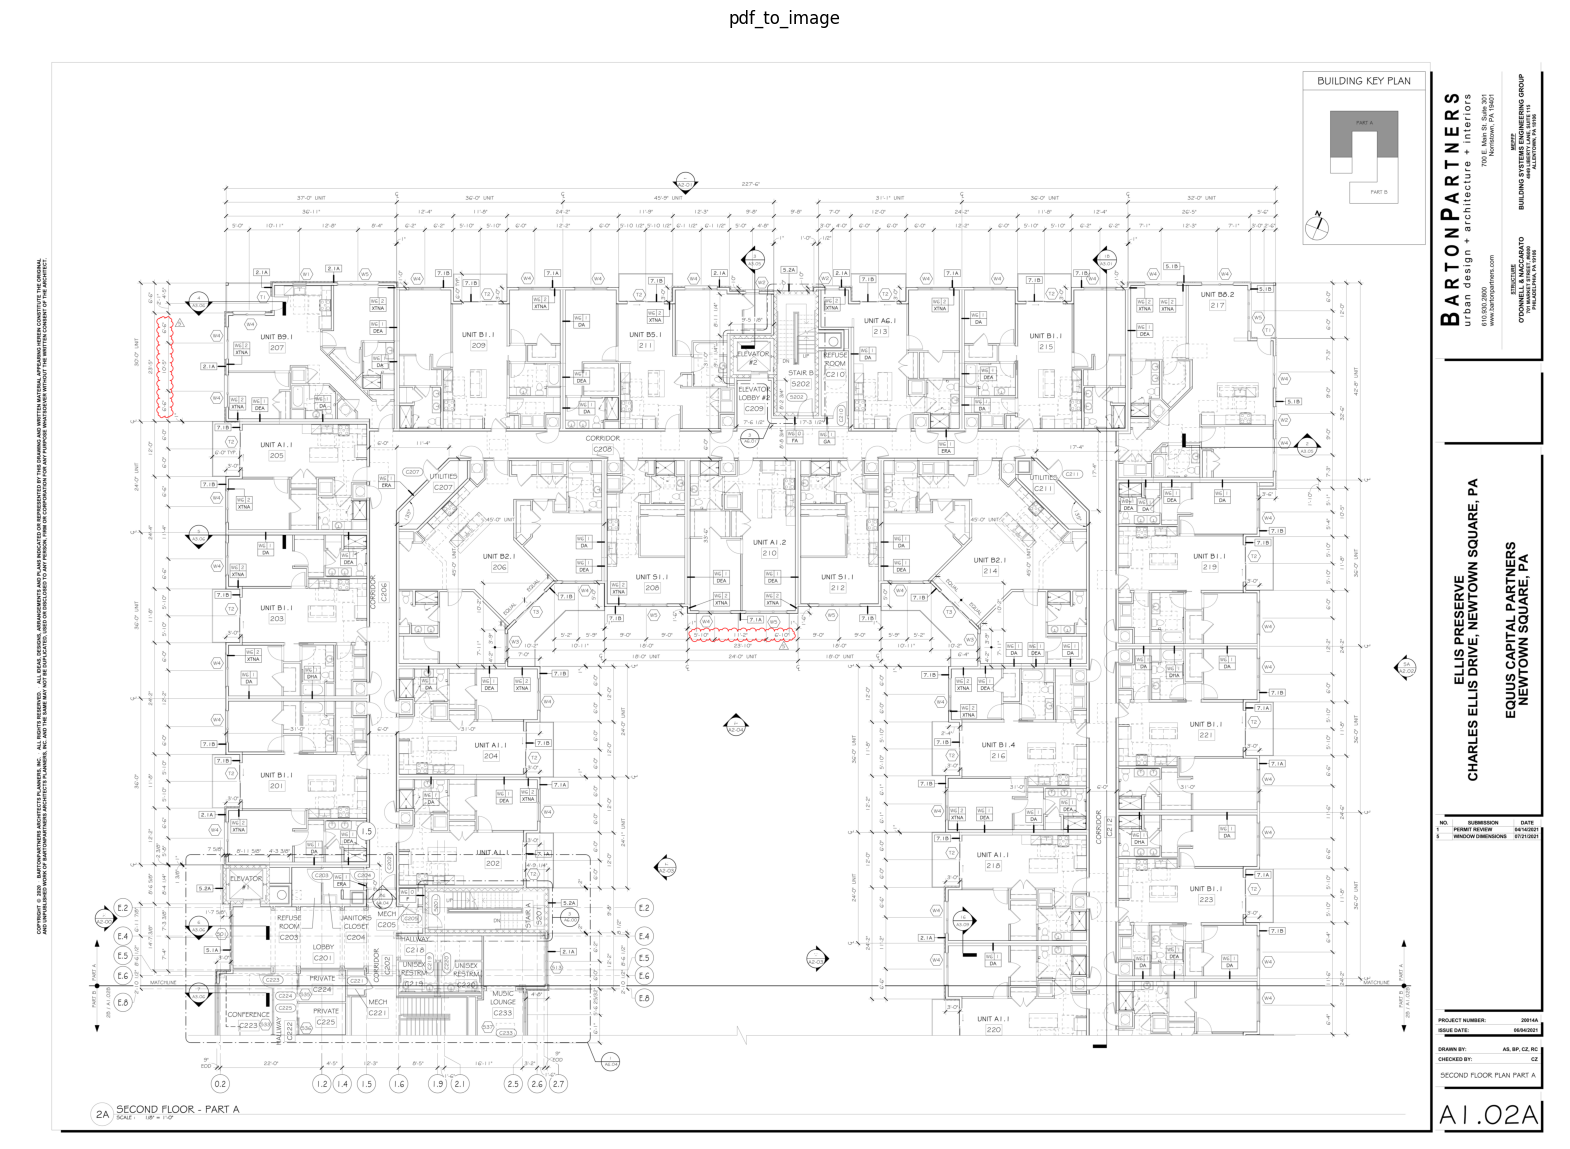

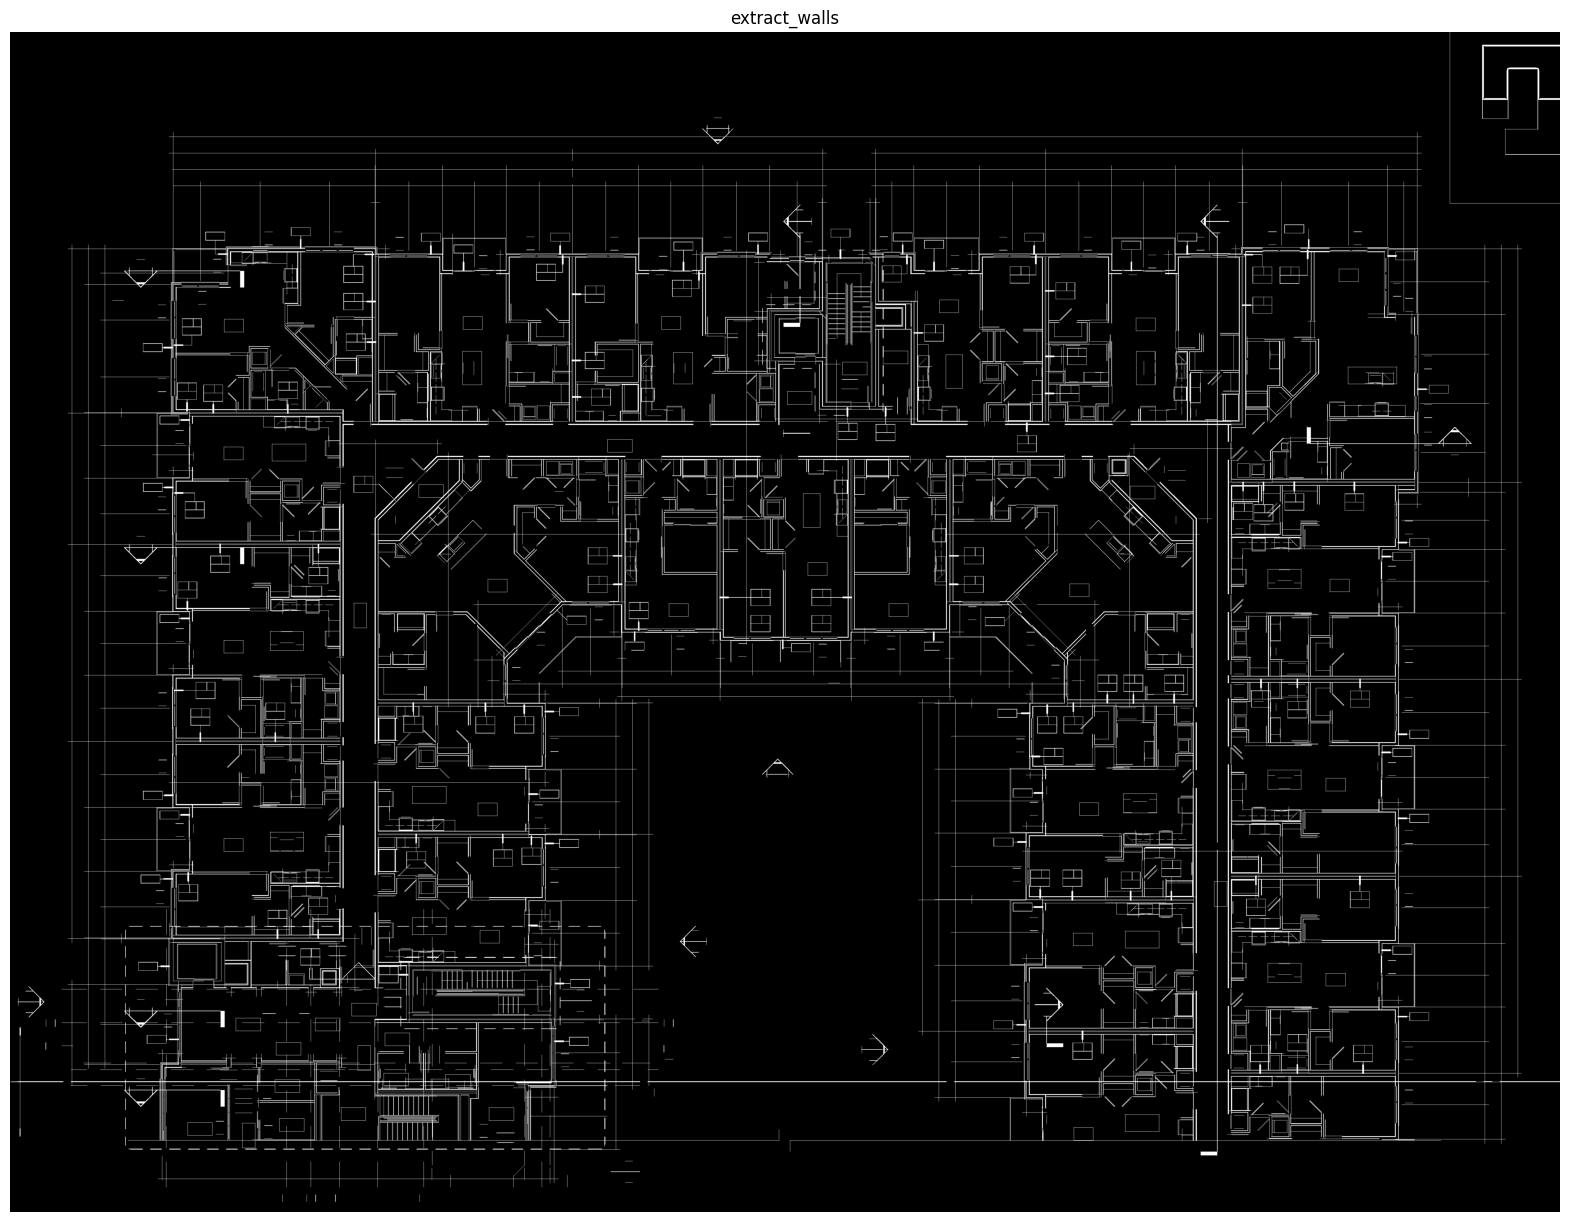

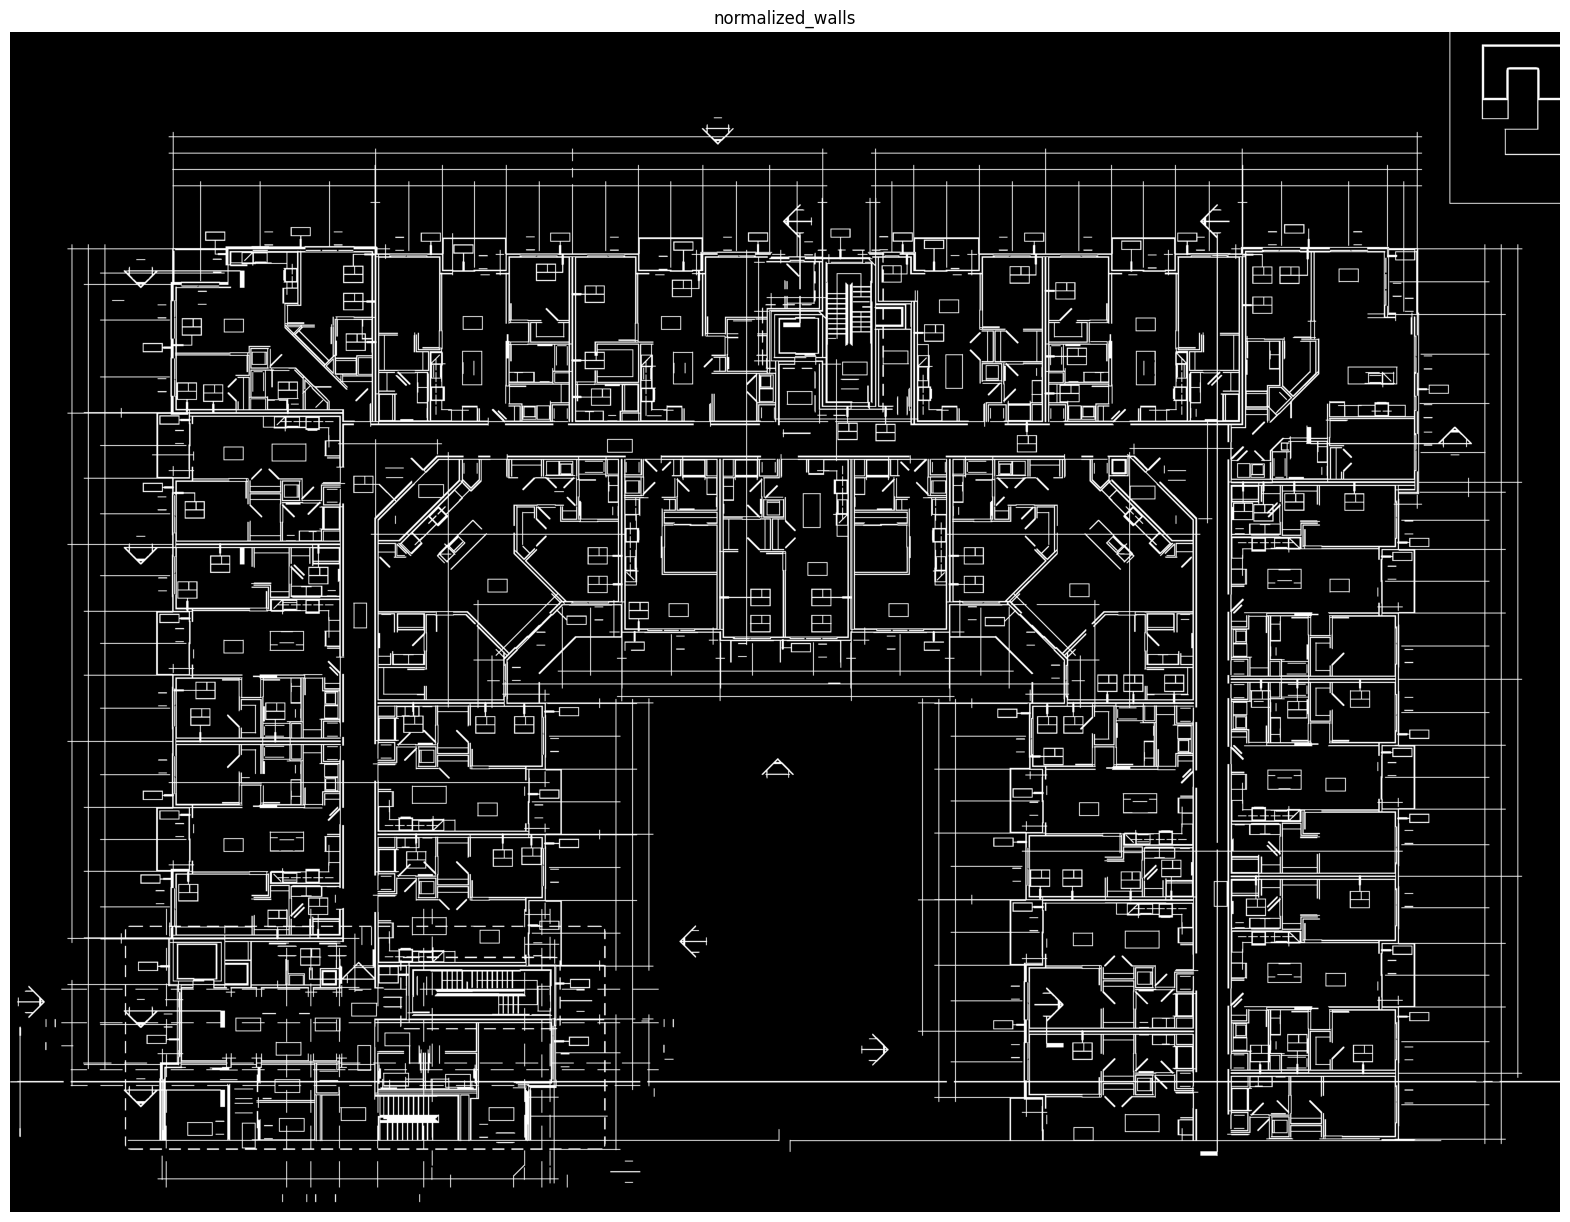

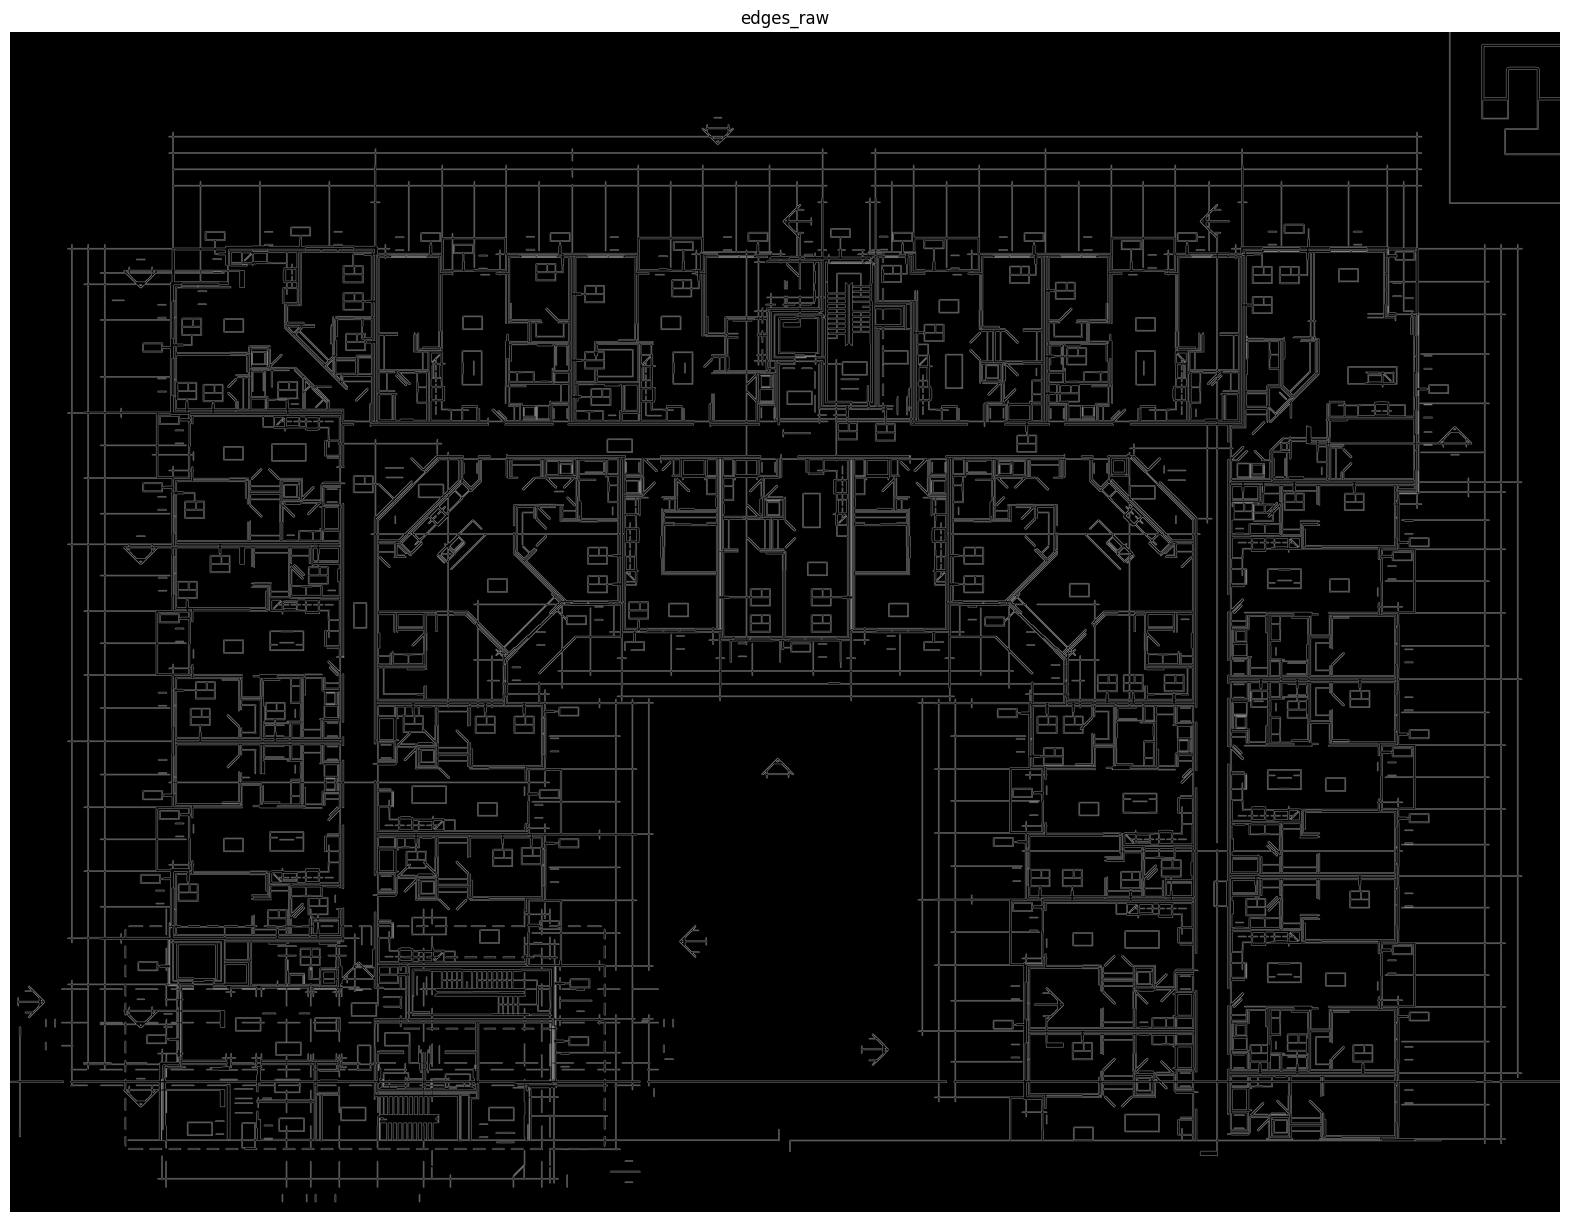

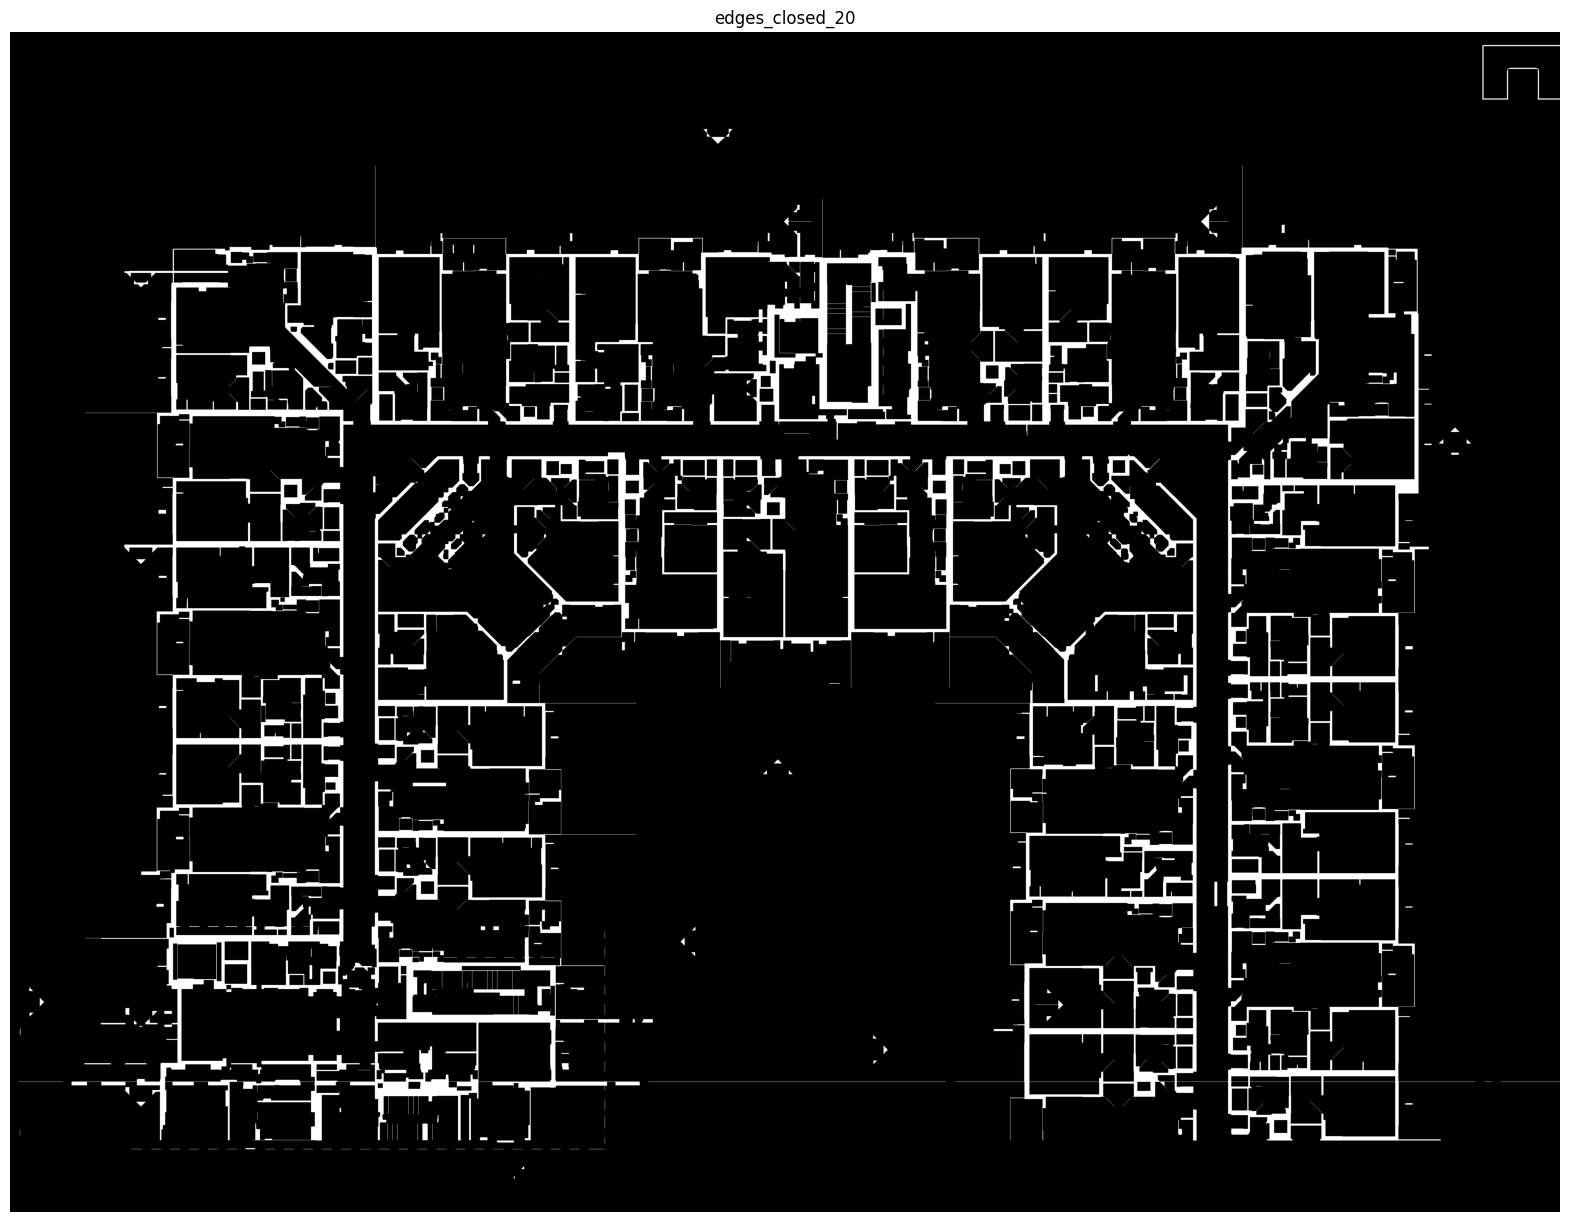

<Figure size 2000x2000 with 0 Axes>

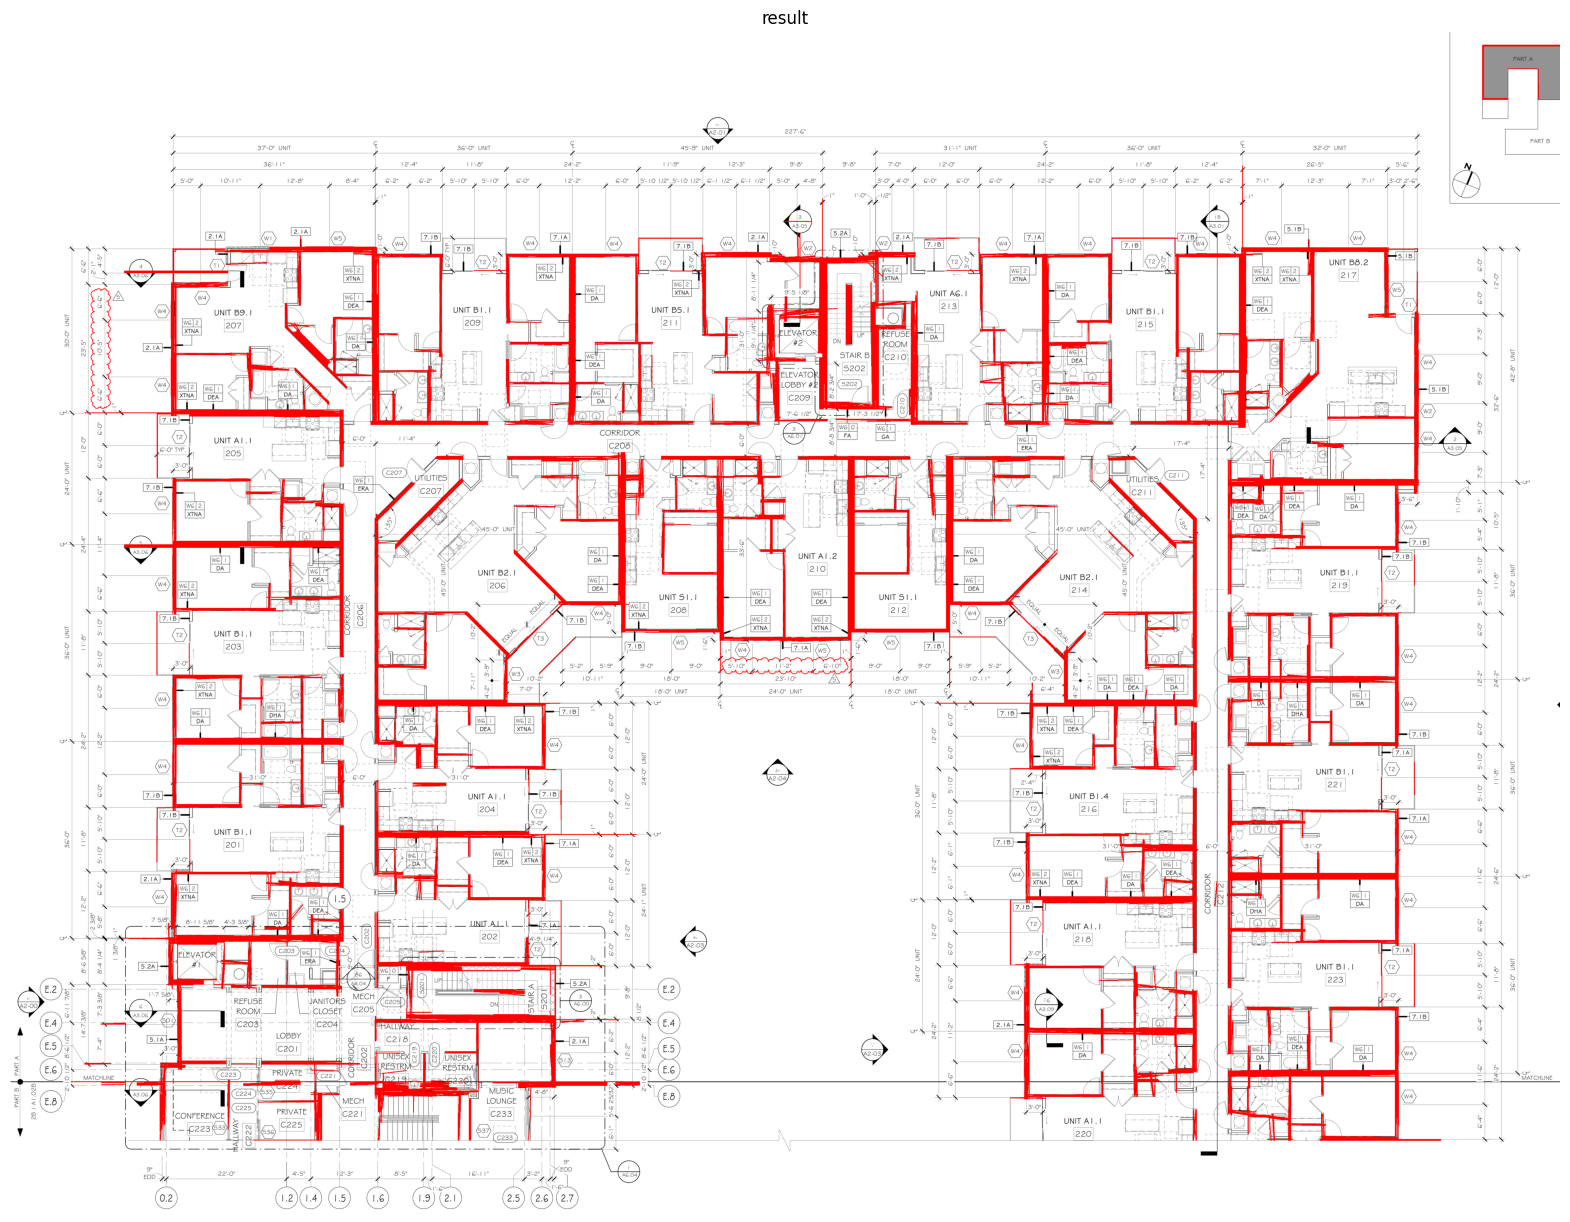

In [27]:
for name, img in process_pdf_steps(sample):
    plt.figure(figsize=(20,20))
    
    if name in ["lines", "filtered_lines"]:
        if name == 'lines':
            lines = img
        else:             
            filtered_lines = img
        continue

    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    plt.title(name)
    plt.axis("off")
    plt.show()